<a href="https://colab.research.google.com/github/DiegoLopezAroca/Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry/blob/main/Project_Proposal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D2.1 - Project Proposal for the time series analysis delivery**
The aim of this second proposal is to present the ideas we intend to implement with the selected time-series dataset, describe it in depth to analyze its background and study the basic properties of this kind of data.

 This delivery will mainly consist on documentation, but as we must implement some conding analysis, we will present it in a *notebook* format with executable cells.

 Furthermore, this work will be also stored in our [``Github repository``](https://github.com/DiegoLopezAroca/Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry) alongside all the previous material related to the subject.

## **Steel Industry Energy Consumption**
Sourced and available from the well known *UCI Machine Learning Repository*, the selected dataset collects the energy consumption data over time from a company in charge of manufacturing different steel pieces such as coils, steel and iron plates.

<img src="https://imgs.search.brave.com/ESvN_gCRRKdWbUcO7p8AkLrhO1BaXxMl-yZXC8V-Plg/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wNjYv/MzY5LzQxOS9zbWFs/bC9pbmR1c3RyaWFs/LW1ldGFsLXdpcmUt/Y29pbHMtY29pbHMt/b2YtbWV0YWwtd2ly/ZS1hcmUtc3RhY2tl/ZC1vbi1hLWxvYWRp/bmctZG9jay1pbi1h/LWxhcmdlLWluZHVz/dHJpYWwtZmFjaWxp/dHktZHVyaW5nLWRh/eWxpZ2h0LWhvdXJz/LXBob3RvLmpwZw" width="250">

<img src="https://imgs.search.brave.com/PZ3OMLbjSqIO4KVhCtt7duTpXzryO8z7jjU3yPuUIuI/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wNzEv/NDYzLzI4NC9zbWFs/bC9zdGFjay1vZi1z/dGVlbC1wbGF0ZXMt/aW5kdXN0cmlhbC1t/ZXRhbC1zaGVldHMt/bWV0YWwtY29uc3Ry/dWN0aW9uLW1hdGVy/aWFscy1jbG9zZS11/cC1waG90by5qcGc" width="250">

However, further information is also stored in the Korea Electric Power Corporation website, where daily, monthly and annual data is calculated and shown.

Before detailing the time-series properties of the selected data, it is worth going over the different features the dataset consists of (*as clarification, kVarh is the metric unit for reactive energy accumulatd over time*):

### Feature description

*   ``date``: continuous time data feature, with format: *dd/mm/YYYY HH:MM*. It covers the whole 2018 year, with a frecuency of 15 mins.
*   ``Usage_kW``: Usage in kilowatt hours, ranging from 0 up to 175, being the mean around 27,4. As it will be explained later, this will surely be the feature to predict.
*   ``Lagging_Current_Reactive.Power_kVarh``: Reactive power continuous kVarh [0.0-96.9] (mean is 13).
*   ``Leading_Current_Reactive_Power_kVarh``: Leading current reactive power continuous, also in kVarh [0.0-27.8] (mean around 3.87).
*   ``CO2(tCO2)``: Continuous ppm (ranges from 0.0 up to 0.07, mean ~0.01).
*   ``Lagging_Current_Power_Factor``: Reactive power continuous kVarh [0-100] (mean 80.6).

*  ``Leading_Current_Power_Factor``: Leading current reactive power in continuous kVarh (mean 84.4) [0-100].
*   ``NSM``: Number of seconds form midnight [0-85.5k] (mean around 42.8k).
*   ``WeekStatus``: Binary feature indicating whether is weekend (0) or weekday (1). As expected, almost 3/4 of the instances are weekdays.
*   ``Day_of_week``: day of the week.

(A deeper analysis of the features will be found in the following cells)

### Time series properties
As mentioned above in the date feature, there is record of a complete year in a high frequency of 15 mins per instance. Starting from ``01-01-2018 00:15`` until ``31-12-2018 23:45``, and there is only one single time series (``Usage_kWh``).

When it comes to some properties that could be related to seasonality aspects, both the ``NSM`` and ``WeekStatus`` capture time trends and cycles. The first feature covering a complete daily cycle (inherently capturing the daily patterns of consumption), while the second catches the weekly patterns.

On the other hand, *exogenous variables* are those factors whose value is determined outside the system and directly imposed on the model, being totally independent to the input. In our case there are several columns that could influence on the consumption feature.

Here's a detailed breakdown of potential exogenous variables and their expected influence on the 'Usage_kWh' feature:

*   Both ``Lagging_Current_Reactive.Power_kVarh`` and ``Leading_Current_Reactive_Power_kVarh``: These reactive power measurements are direct indicators of electrical load characteristics and can significantly impact the overall energy usage.
*   ``CO2(tCO2)``: Fluctuations in CO2 could indicate periods of higher or lower industrial activity, thus affecting energy usage.
*   ``NSM``: As mentioned above, this feature captures the time of day, which is a strong predictor of energy demand due to operational schedules and shifts (the same could be said about the other features that capture time data).
*  ``Load_Type``: Describes the operational state of the facility (Light, Medium, Maximum Load), which is expected to have a direct and strong correlation with ``Usage_kWh``.

### Dataset Loading
We will implement the desired loading format as in the previous delivery

In [4]:
# from pydrive2.auth import GoogleAuth
# from pydrive2.drive import GoogleDrive
# from google.colab import auth
# from oauth2client.client import GoogleCredentials
# from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf


In [ ]:
auth.authenticate_user()
google_auth = GoogleAuth()
google_auth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(google_auth)

In [ ]:
file_id = '1FLKVRjZcWCm3zBcNElhfEZm3KAzRW3PQ'
file = drive.CreateFile({'id':file_id})
file.GetContentFile('steel_industry_energy_dataset.csv')

df = pd.read_csv('steel_industry_energy_dataset.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [6]:
df = pd.read_csv('data/Steel_industry_data.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [8]:
df[['date', 'WeekStatus', 'Day_of_week']].head() # columns time-series related

,date,WeekStatus,Day_of_week
0,01/01/2018 00:15,Weekday,Monday
1,01/01/2018 00:30,Weekday,Monday
2,01/01/2018 00:45,Weekday,Monday
3,01/01/2018 01:00,Weekday,Monday
4,01/01/2018 01:15,Weekday,Monday


In [9]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")

In [10]:
categorical_cols = df.select_dtypes("object")
for c in df.select_dtypes("object"):
  print(f"Class distribution for categorical column {c}:")
  print(f"{df[c].value_counts(normalize=True)*100}\n")

Class distribution for categorical column WeekStatus:
WeekStatus
Weekday    71.506849
Weekend    28.493151
Name: proportion, dtype: float64

Class distribution for categorical column Day_of_week:
Day_of_week
Monday       14.520548
Tuesday      14.246575
Wednesday    14.246575
Thursday     14.246575
Friday       14.246575
Saturday     14.246575
Sunday       14.246575
Name: proportion, dtype: float64

Class distribution for categorical column Load_Type:
Load_Type
Light_Load      51.575342
Medium_Load     27.671233
Maximum_Load    20.753425
Name: proportion, dtype: float64



C:\Users\diego\AppData\Local\Temp\ipykernel_19372\3281102846.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes("object")
C:\Users\diego\AppData\Local\Temp\ipykernel_19372\3281102846.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration

Plotting (barkatu desordenagatik)

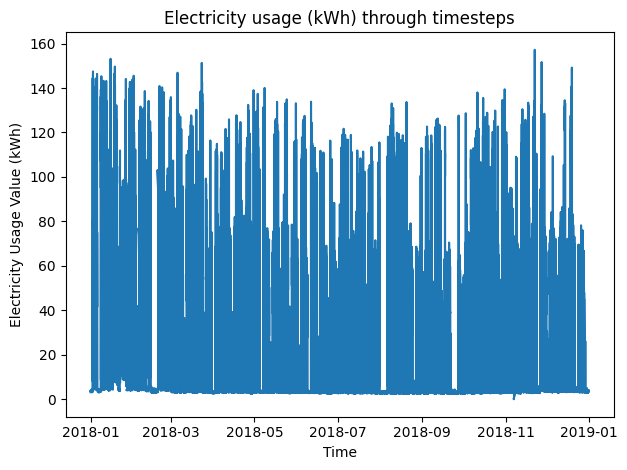

In [11]:
def visualize_time_series(dataframe):
    fig, ax = plt.subplots()
    ax.plot(dataframe["date"], dataframe["Usage_kWh"])
    ax.set_xlabel('Time') # Is just the sequential order
    ax.set_ylabel('Electricity Usage Value (kWh)') # The randomly given value
    plt.title("Electricity usage (kWh) through timesteps")
    plt.tight_layout()

visualize_time_series(df)

## Forecasting objective
Briefly describe the objective of the forecasting project, highlighting the specific time
series data being analyzed and the forecasting goals (e.g., predicting electrical
consumption for the next month). You should also define the forecasting horizon (e.g.,
one week ahead, one month ahead) and rationale behind choosing this horizon.

Our goal is to predict the future 24h electric consumption based on the 15 minutes intervals, recorded during the day for one complete year. The rationale behind this decision is that a 24 hour horizon permits the factory/plant to adjust their production times based on the cost of energy and ensure that the renewable energy supply is enough.

Furthermore, our decision is supported by the importance of peak shaving, which refers to leveling out peaks in electricity use by industrial and commercial power consumers. This is not only useful to keep the grid stable (staying within the limits of contracted power), but also for economic efficiency. In many industrial sectors electricity prices for large-scale consumers are set with reference to their maximum peak-load. Therefore, having an accurate forecasting could allow the plant to avoid costly surcharges. 

**(References from where we have retreived this information in reference section)**

## Time-series properties analysis
**Stationarity** and **random walk** analysis. Remember that you can not select a random
walk for the assignment.

In order to know whether we are working with a random walk or not we will check the stationarity. To do so we have to prove the Dickey-Fuller test and reject the null hypothesis.

In [16]:
# Stationarity check with ADF test
ADF_result = adfuller(df['Usage_kWh']) # Apply to the time series column
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]:.4f}')

ADF Statistic: -24.281836827446377
p-value: 0.0000


As the p-value is less than 0.05 we can reject the null hypothesis and confirm that the time series is stationary (constant mean and variance).

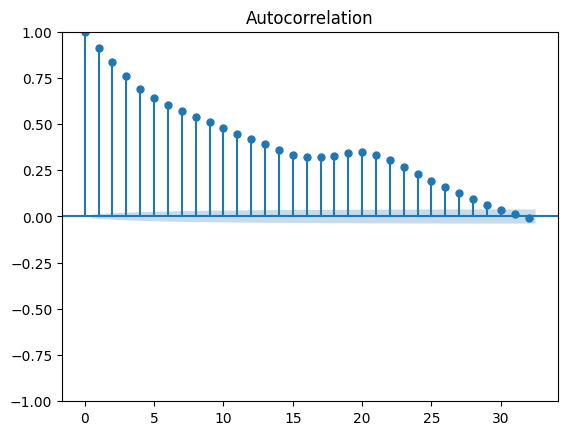

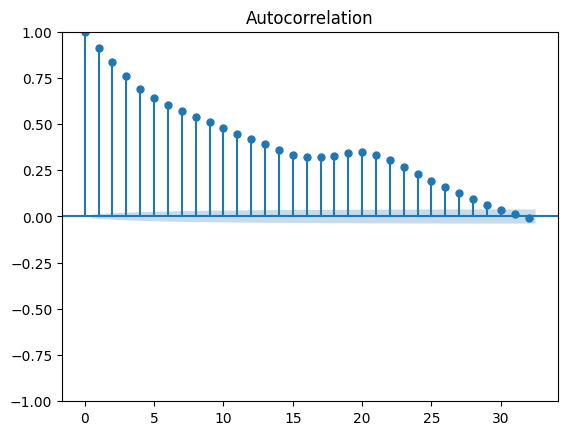

In [24]:
# Plus plotting
plot_acf(df['Usage_kWh'], lags=32) # Apply to the time series column

## Previous work study
Luckily, the *Kaggle* page did offer the links to the most relevant papers in which the dataset has been used. For each available resource, we will mark down the desired task and the methods involved to achieve it.



1.   The first paper (referenced below), published in 2021 by several korean investigators, uses the dataset to over the rapid development of urban advancements in buildings and infra-structures in South Korea. Using data-mining techniques and five different shallow machine learning predictive algorithms, the article studies the energy consumption of energy collected using IoT systems in a small industry in Korea. Those predictive algorithms are a *linear regression*, *classification and regression trees*, *SVMs (with a radial basis kernel)*, *KNN* and *CUBIST* (this last algorithm showed the best results). And the most basic metrics were used to evaluate the predictions: *RSME* (root squared mean error), *MAE* (mean absolute error), ... etc. The *CUBIST* algorithm which we have not covered in class, is a rule-based regression that generates models combining decision trees with linear regressions.

2.   Another Korean paper where similar data mining and predictive algorithms are used over the same set of data. Nevertheless, different models were developed and different metrics were used for evaluation. Apart from the *linear regression* and the *SVM (rbf kernel)* used in the first paper, a *gradient boosting machine* and *random forest* were used. The metrics used are the same, resulting in the *random forest* being the best predictor.


3.    This third paper (also Korean) mainly focuses on the same idea of implementing data mining techniques. The only thing that varies are the algorithms used and the evaluating metrics.

As we can see, studies where shallow ML techniques are applied to the dataset are available, so there is no other we can use as inspiration and guidance to develop our time series analysis for this delivery.


## References
*   [```Steel Industry Energy Consumption (UCI Machine Learning Repository)```](https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption)

*   [```Steel Industry Energy Consumption (Kaggle)```](https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption)
*   [```Predicción de la demanda de electricidad```](https://www.iic.uam.es/soluciones/energia/prediccion-demanda-energia/prediccion-demanda-electricidad/)
*   [```What does Peak shaving mean?```](https://www.next-kraftwerke.com/en-US/knowledge/what-is-peak-shaving#peak-loads-and-grid-usage-fees)
*   [```Efficient energy consumption prediction model for a data analytic-enabled industry building in a smart city (paper 1)```](https://www.tandfonline.com/doi/abs/10.1080/09613218.2020.1809983)
*   [```cubist 1.2.1 (CUBIST algorihtm)```](https://pypi.org/project/cubist/)

*   [```An Energy Consumption Prediction Model for Smart Factory Using Data Mining Algorithms (paper 2)```](https://www.kci.go.kr/kciportal/ci/sereArticleSearch/ciSereArtiView.kci?sereArticleSearchBean.artiId=ART002589315)

*   [```Industry Energy Consumption Prediction Using Data Mining Techniques (paper 3)```](https://www.researchgate.net/publication/341212598_Industry_Energy_Consumption_Prediction_Using_Data_Mining_Techniques)